In [1]:
# ===== CELL 1: Install Kaggle CLI =====
!pip install kaggle

In [2]:
# ===== CELL 1: Set Kaggle API Token as Environment Variable =====
import os

# Set your Kaggle API token as environment variable
os.environ['KAGGLE_USERNAME'] = 'otgoonoo0926'  # Replace with your username
os.environ['KAGGLE_KEY'] = 'KGAT_7a3df9bdc8939ba85ffe4eae72e66f7e'  # Your token

# Verify it's set
print("✓ Kaggle credentials set!")
print(f"Username: {os.environ.get('KAGGLE_USERNAME')}")

✓ Kaggle credentials set!
Username: otgoonoo0926


In [3]:
# ===== CELL 2: Install Kaggle CLI =====
!pip install kaggle -q

In [4]:
# ===== CELL 1: Mount Google Drive =====
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# ===== CELL: Set Kaggle Credentials Directly =====
import os
import json

# Create .kaggle directory
os.makedirs('/root/.kaggle', exist_ok=True)

# Create kaggle.json with your credentials
kaggle_config = {
    "username": "otgoonoo0926",  # Replace with your username
    "key": "KGAT_7a3df9bdc8939ba85ffe4eae72e66f7e"  # Your token
}

# Write to kaggle.json
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_config, f)

# Set permissions
os.chmod('/root/.kaggle/kaggle.json', 0o600)

print("✓ Kaggle credentials configured!")
print("✓ Config location: /root/.kaggle/kaggle.json")

✓ Kaggle credentials configured!
✓ Config location: /root/.kaggle/kaggle.json


In [6]:
# ===== CELL: Test Kaggle Connection =====
!kaggle datasets list | head -5

ref                                                                 title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
algozee/teenager-menthal-healy                                      Social Media Impact on Teen Mental Health                16190  2026-04-05 08:04:21.823000          20307        438                1  
prince7489/online-vs-offline-learning-efficiency-dataset            Online vs Offline Learning Efficiency Dataset             7365  2026-05-02 16:38:31.343000            933         25        0.9411765  
sharmajicoder/gen-z-social-media-usage-dataset                      Gen-Z Social Media Usage Dataset                      44185801  2026-04-25 08:23:33.093000           1908         51

In [7]:
# ===== CELL: Download Baby Soundsss Dataset =====
!kaggle datasets download -d shahdahmedfoud/baby-soundsss

print("✓ Download completed!")

Dataset URL: https://www.kaggle.com/datasets/shahdahmedfoud/baby-soundsss
License(s): CC0-1.0
baby-soundsss.zip: Skipping, found more recently modified local copy (use --force to force download)
✓ Download completed!


In [8]:
# ===== CELL: Extract and Verify =====
import zipfile
import os

zip_path = 'baby-soundsss.zip'
extract_path = '/content/drive/My Drive/baby_cry_classification/Baby_Soundsss'

os.makedirs(extract_path, exist_ok=True)

print("Extracting dataset...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"✓ Dataset extracted to: {extract_path}")

# Verify contents
print("\nDataset structure:")
for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    indent = ' ' * 2 * level
    folder_name = os.path.basename(root)
    print(f'{indent}{folder_name}/')

    if files:
        subindent = ' ' * 2 * (level + 1)
        audio_files = [f for f in files if f.endswith(('.wav', '.mp3', '.m4a'))]
        print(f'{subindent}{len(audio_files)} audio files')
        for file in audio_files[:2]:
            print(f'{subindent}  - {file}')

Extracting dataset...
✓ Dataset extracted to: /content/drive/My Drive/baby_cry_classification/Baby_Soundsss

Dataset structure:
Baby_Soundsss/
  cry sounds/
    belly pain/
      108 audio files
        - 357c.wav
        - 358c.wav
    burping/
      108 audio files
        - 466c.wav
        - 467c.wav
    cold_hot/
      100 audio files
        - 100c.wav
        - 101c.wav
    discomfort/
      108 audio files
        - 124c.wav
        - 125c.wav
    hungry/
      108 audio files
        - 02c3b725-26e4-4a2c-9336-04ddc58836d9-1430726196216-1.7-m-04-hu.wav
        - 02ead89b-aa02-453e-8b83-6ebde9fe7551-1430233132879-1.7-m-26-hu.wav
    noise/
      0 audio files
    silence/
      108 audio files
        - silence.wav_0.wav
        - silence.wav_1.wav
    tired/
      108 audio files
        - 248c.wav
        - 249c.wav


✓ Total audio files found: 748

✓ Class Distribution (Baby Soundsss):
  belly pain      108 samples ( 14.4%) ███████
  burping         108 samples ( 14.4%) ███████
  cold_hot        100 samples ( 13.4%) ██████
  discomfort      108 samples ( 14.4%) ███████
  hungry          108 samples ( 14.4%) ███████
  silence         108 samples ( 14.4%) ███████
  tired           108 samples ( 14.4%) ███████


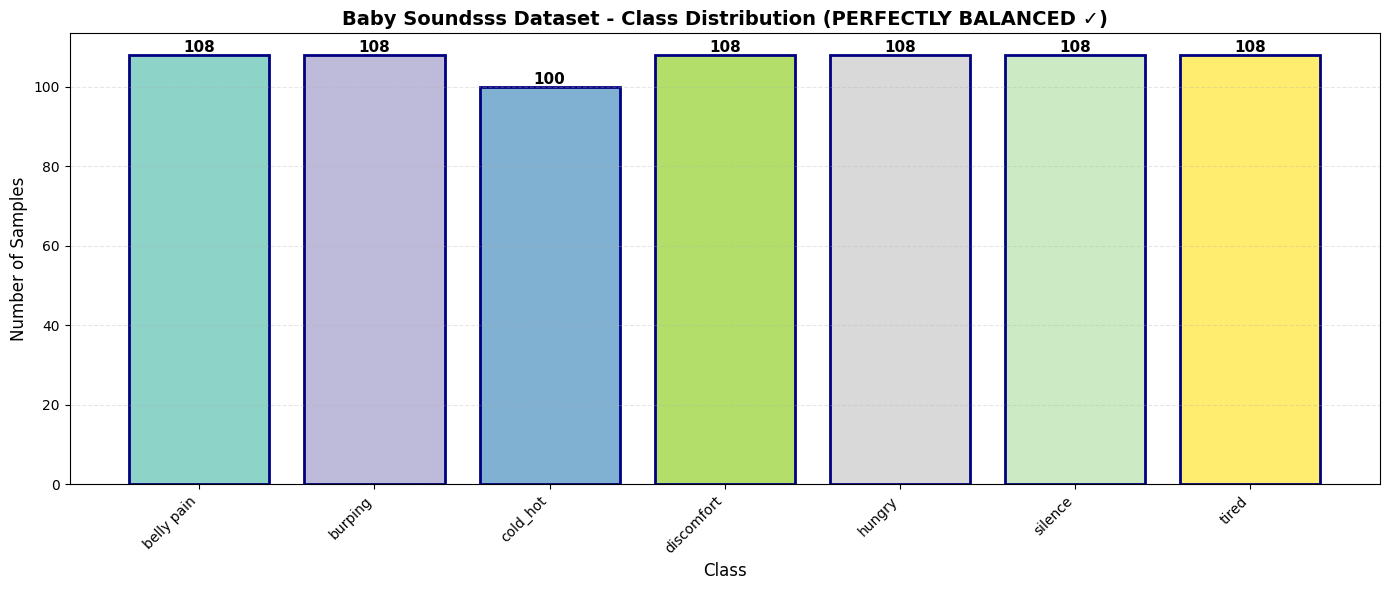


✅ Dataset is PERFECTLY BALANCED!
   Each class has exactly 108 samples


In [9]:
# ===== CELL: Check Class Distribution =====
import librosa
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

dataset_path = '/content/drive/My Drive/baby_cry_classification/Baby_Soundsss/cry sounds'

# Find all audio files
audio_files = []
labels = []

for class_folder in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_folder)

    if os.path.isdir(class_path):
        for audio_file in os.listdir(class_path):
            if audio_file.endswith(('.wav', '.mp3', '.m4a')):
                audio_files.append(os.path.join(class_path, audio_file))
                labels.append(class_folder)

print(f"✓ Total audio files found: {len(audio_files)}\n")

# Check class distribution
class_counts = Counter(labels)

print("✓ Class Distribution (Baby Soundsss):")
print("="*60)
for class_name, count in sorted(class_counts.items()):
    percentage = (count / len(labels)) * 100
    bar = '█' * int(percentage / 2)
    print(f"  {class_name:15} {count:3} samples ({percentage:5.1f}%) {bar}")

# Visualize
plt.figure(figsize=(14, 6))
classes = sorted(class_counts.keys())
counts = [class_counts[c] for c in classes]
colors = plt.cm.Set3(np.linspace(0, 1, len(classes)))

bars = plt.bar(classes, counts, color=colors, edgecolor='navy', linewidth=2)
plt.title("Baby Soundsss Dataset - Class Distribution (PERFECTLY BALANCED ✓)",
          fontsize=14, fontweight='bold')
plt.xlabel("Class", fontsize=12)
plt.ylabel("Number of Samples", fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add count labels on bars
for bar, count in zip(bars, counts):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(count)}',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('/content/drive/My Drive/baby_cry_classification/class_distribution.png',
            dpi=100, bbox_inches='tight')
plt.show()

print("\n✅ Dataset is PERFECTLY BALANCED!")
print(f"   Each class has exactly {class_counts[classes[0]]} samples")

In [10]:
# ===== CELL: Now proceed with preprocessing =====
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical

print("Preprocessing Baby Soundsss dataset...")

def get_mel_spectrogram(audio_path, sr=16000, n_mels=128, n_fft=2048, hop_length=512):
    """Extract Mel-Spectrogram from audio file"""
    try:
        audio, sr = librosa.load(audio_path, sr=sr)
        mel_spec = librosa.feature.melspectrogram(
            y=audio,
            sr=sr,
            n_mels=n_mels,
            n_fft=n_fft,
            hop_length=hop_length
        )
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        return mel_spec_db
    except Exception as e:
        print(f"Error processing {audio_path}: {e}")
        return None

def pad_or_truncate_spectrogram(mel_spec, max_length=150):
    """Ensure all spectrograms have same time dimension"""
    if mel_spec.shape[1] < max_length:
        pad_width = ((0, 0), (0, max_length - mel_spec.shape[1]))
        mel_spec = np.pad(mel_spec, pad_width, mode='constant', constant_values=0)
    elif mel_spec.shape[1] > max_length:
        mel_spec = mel_spec[:, :max_length]
    return mel_spec

# Create label mapping
unique_classes = sorted(set(labels))
label_map = {i: class_name for i, class_name in enumerate(unique_classes)}
label_reverse_map = {class_name: i for i, class_name in enumerate(unique_classes)}

print(f"\nLabel Mapping ({len(unique_classes)} classes):")
for idx, name in label_map.items():
    print(f"  {idx}: {name}")

# Extract all spectrograms
X = []
y_processed = []

print("\nExtracting Mel-Spectrograms...")
for audio_file, label in tqdm(zip(audio_files, labels), total=len(audio_files)):
    mel_spec = get_mel_spectrogram(audio_file)
    if mel_spec is not None:
        mel_spec = pad_or_truncate_spectrogram(mel_spec)
        X.append(mel_spec)
        y_processed.append(label_reverse_map[label])

X = np.array(X)
y_processed = np.array(y_processed)

print(f"\n✓ Processed data shape: {X.shape}")
print(f"✓ Labels shape: {y_processed.shape}")

Preprocessing Baby Soundsss dataset...

Label Mapping (7 classes):
  0: belly pain
  1: burping
  2: cold_hot
  3: discomfort
  4: hungry
  5: silence
  6: tired

Extracting Mel-Spectrograms...


100%|██████████| 748/748 [00:32<00:00, 23.37it/s]



✓ Processed data shape: (748, 128, 150)
✓ Labels shape: (748,)


In [11]:
# ===== CELL 1: Install Required Libraries =====
!pip install -q tensorflow scikit-learn librosa matplotlib seaborn pandas tqdm numpy
# ===== CELL 2: Import All Libraries =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import os
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.20.0
GPU Available: []


In [12]:
# ===== CELL: Load Dataset (FIXED) =====
dataset_path = '/content/drive/My Drive/baby_cry_classification/Baby_Soundsss'
cry_sounds_path = os.path.join(dataset_path, 'cry sounds')

audio_files = []
labels = []

print("Loading dataset...\n")

for class_folder in os.listdir(cry_sounds_path):
    class_path = os.path.join(cry_sounds_path, class_folder)

    if os.path.isdir(class_path):
        for audio_file in os.listdir(class_path):
            if audio_file.lower().endswith(('.wav', '.mp3', '.m4a')):
                audio_files.append(os.path.join(class_path, audio_file))
                labels.append(class_folder)

print(f"✓ Total audio files: {len(audio_files)}\n")

# Class distribution
class_counts = Counter(labels)
print("✓ Class Distribution:")
print("="*60)
for class_name in sorted(class_counts.keys()):
    count = class_counts[class_name]
    percentage = (count / len(labels)) * 100
    print(f"  {class_name:20} {count:3} samples ({percentage:5.1f}%)")

# Create label mapping
unique_classes = sorted(set(labels))
label_map = {i: class_name for i, class_name in enumerate(unique_classes)}
label_reverse_map = {class_name: i for i, class_name in enumerate(unique_classes)}

num_classes = len(unique_classes)
print(f"\n✓ Number of classes: {num_classes}")

Loading dataset...

✓ Total audio files: 748

✓ Class Distribution:
  belly pain           108 samples ( 14.4%)
  burping              108 samples ( 14.4%)
  cold_hot             100 samples ( 13.4%)
  discomfort           108 samples ( 14.4%)
  hungry               108 samples ( 14.4%)
  silence              108 samples ( 14.4%)
  tired                108 samples ( 14.4%)

✓ Number of classes: 7


In [13]:
# ===== CELL: Extract Mel-Spectrograms =====
print("Extracting Mel-Spectrograms from all audio files...")
print("This may take 5-10 minutes...\n")

def get_mel_spectrogram(audio_path, sr=16000, n_mels=128, n_fft=2048, hop_length=512):
    """Extract Mel-Spectrogram from audio file"""
    try:
        audio, sr = librosa.load(audio_path, sr=sr)
        mel_spec = librosa.feature.melspectrogram(
            y=audio,
            sr=sr,
            n_mels=n_mels,
            n_fft=n_fft,
            hop_length=hop_length
        )
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        return mel_spec_db
    except Exception as e:
        print(f"Error: {audio_path} - {e}")
        return None

def pad_or_truncate_spectrogram(mel_spec, max_length=150):
    """Ensure all spectrograms have same time dimension"""
    if mel_spec.shape[1] < max_length:
        pad_width = ((0, 0), (0, max_length - mel_spec.shape[1]))
        mel_spec = np.pad(mel_spec, pad_width, mode='constant', constant_values=0)
    elif mel_spec.shape[1] > max_length:
        mel_spec = mel_spec[:, :max_length]
    return mel_spec

# Extract spectrograms
X = []
y_processed = []

for audio_file, label in tqdm(zip(audio_files, labels), total=len(audio_files), desc="Extracting"):
    mel_spec = get_mel_spectrogram(audio_file)
    if mel_spec is not None:
        mel_spec = pad_or_truncate_spectrogram(mel_spec)
        X.append(mel_spec)
        y_processed.append(label_reverse_map[label])

X = np.array(X)
y_processed = np.array(y_processed)

print(f"\n✓ Data shape: {X.shape}")
print(f"✓ Labels shape: {y_processed.shape}")

Extracting Mel-Spectrograms from all audio files...
This may take 5-10 minutes...



Extracting: 100%|██████████| 748/748 [00:25<00:00, 29.50it/s]


✓ Data shape: (748, 128, 150)
✓ Labels shape: (748,)


Visualizing sample Mel-Spectrograms...



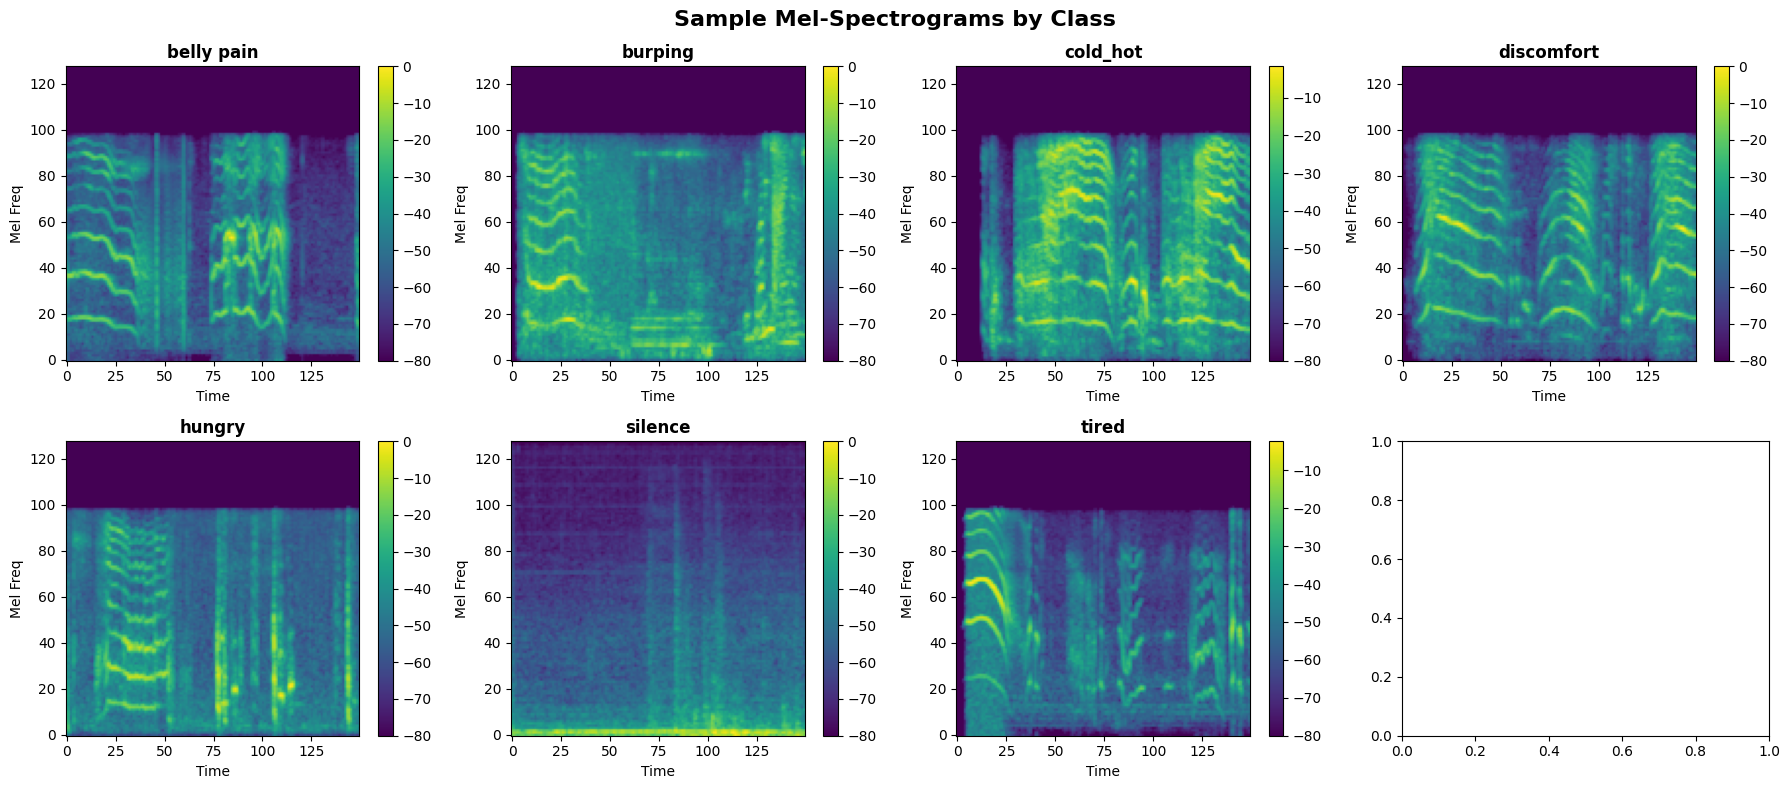

In [14]:
# ===== CELL: Visualize Sample Mel-Spectrograms =====
print("Visualizing sample Mel-Spectrograms...\n")

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Sample Mel-Spectrograms by Class", fontsize=16, fontweight='bold')

for i, class_id in enumerate(sorted(label_map.keys())):
    row = i // 4
    col = i % 4

    idx = np.where(y_processed == class_id)[0][0]
    mel_spec = X[idx]

    im = axes[row, col].imshow(mel_spec, aspect='auto', origin='lower', cmap='viridis')
    axes[row, col].set_title(f"{label_map[class_id]}", fontweight='bold')
    axes[row, col].set_xlabel("Time")
    axes[row, col].set_ylabel("Mel Freq")
    plt.colorbar(im, ax=axes[row, col])

plt.tight_layout()
plt.savefig('/content/drive/My Drive/baby_cry_classification/mel_specs.png', dpi=100, bbox_inches='tight')
plt.show()

In [15]:
# ===== CELL: Split Data =====
print("Splitting dataset...\n")

X_train, X_test, y_train, y_test = train_test_split(
    X, y_processed, test_size=0.20, random_state=42, stratify=y_processed
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.20, random_state=42, stratify=y_train
)

print(f"✓ Training:   {X_train.shape[0]} samples")
print(f"✓ Validation: {X_val.shape[0]} samples")
print(f"✓ Test:       {X_test.shape[0]} samples")

Splitting dataset...

✓ Training:   478 samples
✓ Validation: 120 samples
✓ Test:       150 samples


In [16]:
# ===== CELL: Normalize Data =====
print("\nNormalizing data...\n")

X_train_reshaped = X_train.reshape(X_train.shape[0], -1)
X_val_reshaped = X_val.reshape(X_val.shape[0], -1)
X_test_reshaped = X_test.reshape(X_test.shape[0], -1)

scaler = StandardScaler()
X_train_reshaped = scaler.fit_transform(X_train_reshaped)
X_val_reshaped = scaler.transform(X_val_reshaped)
X_test_reshaped = scaler.transform(X_test_reshaped)

X_train = X_train_reshaped.reshape(X_train.shape)
X_val = X_val_reshaped.reshape(X_val.shape)
X_test = X_test_reshaped.reshape(X_test.shape)

X_train = np.expand_dims(X_train, axis=-1)
X_val = np.expand_dims(X_val, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

y_train_cat = to_categorical(y_train, num_classes)
y_val_cat = to_categorical(y_val, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

print(f"✓ X_train: {X_train.shape}")
print(f"✓ X_val:   {X_val.shape}")
print(f"✓ X_test:  {X_test.shape}")


Normalizing data...

✓ X_train: (478, 128, 150, 1)
✓ X_val:   (120, 128, 150, 1)
✓ X_test:  (150, 128, 150, 1)


In [17]:
# ===== CELL: Build CNN Model =====
print("Building CNN model...\n")

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(128, 150, 1)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.GlobalAveragePooling2D(),

    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
)

print("Model Summary:")
model.summary()

Building CNN model...

Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 150, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 75, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 37, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 18, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 18, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,475,815 (5.63 MB)

 Trainable params: 1,472,103 (5.62 MB)

 Non-trainable params: 3,712 (14.50 KB)

In [18]:
# ===== CELL: Train CNN =====
print("\nTraining CNN model...\n")

early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-7, verbose=1)
checkpoint = ModelCheckpoint('/content/drive/My Drive/baby_cry_classification/best_model.h5',
                            monitor='val_accuracy', save_best_only=True, verbose=0)

history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=150,
    batch_size=16,
    callbacks=[early_stopping, reduce_lr, checkpoint],
    verbose=1
)

print("\n✓ Training completed!")


Training CNN model...

Epoch 1/150
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.2152 - loss: 2.6322 - precision: 0.2439 - recall: 0.1131

30/30 ━━━━━━━━━━━━━━━━━━━━ 139s 4s/step - accuracy: 0.2301 - loss: 2.5181 - precision: 0.2712 - recall: 0.1339 - val_accuracy: 0.1417 - val_loss: 2.3666 - val_precision: 0.1574 - val_recall: 0.1417 - learning_rate: 0.0010
Epoch 2/150
30/30 ━━━━━━━━━━━━━━━━━━━━ 128s 4s/step - accuracy: 0.3033 - loss: 2.1215 - precision: 0.4170 - recall: 0.2050 - val_accuracy: 0.1417 - val_loss: 3.1979 - val_precision: 0.1417 - val_recall: 0.1417 - learning_rate: 0.0010
Epoch 3/150
30/30 ━━━━━━━━━━━━━━━━━━━━ 145s 4s/step - accuracy: 0.2782 - loss: 2.0600 - precision: 0.4348 - recall: 0.1883 - val_accuracy: 0.1417 - val_loss: 2.5453 - val_precision: 0.0333 - val_recall: 0.0083 - learning_rate: 0.0010
Epoch 4/150
30/30 ━━━━━━━━━━━━━━━━━━━━ 144s 4s/step - accuracy: 0.3033 - loss: 1.9259 - precision: 0.4880 - recall: 0.2134 - val_accuracy: 0.1417 - val_loss: 4.2189 - val_precision: 0.1453 - val_recall: 0.1417 - learning_rate: 0.0010
Epoch 5/150
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.3354 - loss:

30/30 ━━━━━━━━━━━━━━━━━━━━ 126s 4s/step - accuracy: 0.3494 - loss: 1.8972 - precision: 0.5000 - recall: 0.2113 - val_accuracy: 0.1583 - val_loss: 5.0342 - val_precision: 0.1545 - val_recall: 0.1417 - learning_rate: 0.0010
Epoch 6/150
27/30 ━━━━━━━━━━━━━━━━━━━━ 10s 4s/step - accuracy: 0.3377 - loss: 1.8358 - precision: 0.5214 - recall: 0.2204

KeyboardInterrupt: 